- **[1] Pandas: 기초**
    
    ### **[실습] 기본 실습**
    
    | Name | Age | City | Salary |
    | --- | --- | --- | --- |
    | Alice | 25 | New York | 70000 |
    | Bob | 30 | Los Angeles | 80000 |
    | Charlie | 35 | Chicago | 120000 |
    | David | 40 | Houston | 90000 |
    | Eve | 28 | San Francisco | 75000 |
    - 다음 데이터를 활용하여 실습 문제를 해결하세요.
    1. **DataFrame객체 생성 :** 위의 데이터를 사용해 DataFrame객체를 생성하세요.
    2. **열과 행 선택**
        - `Name`과 `City` 열을 선택하여 출력하세요.
        - 나이가 30 이상인 행을 선택하여 출력하세요.
    3. **행과 열 추가**
        - `Country` 열을 추가하고, 모두 'USA'로 설정하세요.
        - 새로운 행을 추가하세요. (Name: Frank, Age: 33, City: Seattle, Salary: 85000)
    4. **데이터 삭제**
        - `Salary` 열을 삭제하세요.
        - 'David'가 있는 행을 삭제하세요.
    5. **데이터 수정**
        - `Age`가 35 이상인 사람들의 `Salary`를 5% 증가시키세요.
        - 'Alice'의 `City`를 'Boston'으로 수정하세요.
    6. **데이터 타입 변환**
        - `Age`와 `Salary`의 데이터 타입을 float로 변환하세요.

In [ ]:
import pandas as pd

# 1.
df = pd.DataFrame({
    'name':['Alice','Bob','Charlie','David','Eve']
    ,'age':[25, 30, 35, 40, 28]
    ,'city':['New York','LA','Chicago','Houston','San Francisco']
    ,'salary':[70000,80000,120000,90000,75000]
    
})
print("################## 1 ##################")
print(df)

print("################## 2 ##################")
# 2.
print(df.loc[df['age']>=30,['name','age']])

print("################## 3 ##################")
# 3.
df["country"] = ['USA', 'USA', 'USA', 'USA', 'USA']
df.loc[5] = ['Frank',33,'Seatle',85000,'USA']
print(df)

# 4. **데이터 삭제**
print("################## 4 ##################")
df = df.drop("salary",axis=1)
df.drop(df[df["name"]=="David"].index, inplace=True)
print(df)



In [ ]:
# 5. **데이터 수정**
#     - `Age`가 35 이상인 사람들의 `Salary`를 5% 증가시키세요.
#     - 'Alice'의 `City`를 'Boston'으로 수정하세요.

print("################## 5 ##################")
df['salary']=[70000,80000,120000,90000,75000]
df.loc[df['age']>=35,'salary'] *= 1.05
df.loc[df["name"]=="Alice",'city'] = 'Boston'
print(df)

    #  6. **데이터 타입 변환**
    #     - `Age`와 `Salary`의 데이터 타입을 float로 변환하세요.
df['age'] = df['age'].astype(float)
df['salary'] = df['salary'].astype(float)
print(df)

### **[실습 1] 데이터 정리 및 전처리**

다음은 직장 내 직원 데이터입니다. 결측된 값들이 포함되어 있습니다. `Salary`와 `YearsAtCompany`의 결측값을 각 열의 평균값으로 채우세요.

employee_data = {
    'EmployeeID': [101, 102, 103, 104, 105],
    'Name': ['John', 'Emily', 'Sara', 'Tom', 'Anna'],
    'Department': ['HR', 'IT', 'Marketing', None, 'HR'],
    'Salary': [50000, 70000, None, 45000, 52000],
    'YearsAtCompany': [5, None, 8, 3, 4]
}

In [44]:
employee_data = {
    'EmployeeID': [101, 102, 103, 104, 105],
    'Name': ['John', 'Emily', 'Sara', 'Tom', 'Anna'],
    'Department': ['HR', 'IT', 'Marketing', None, 'HR'],
    'Salary': [50000, 70000, None, 45000, 52000],
    'YearsAtCompany': [5, None, 8, 3, 4]
}

df = pd.DataFrame(employee_data)

df['Salary'] = df['Salary'].fillna(df['Salary'].mean())
df['YearsAtCompany'] = df['YearsAtCompany'].fillna(df['YearsAtCompany'].mean())
print(df)

   EmployeeID   Name Department   Salary  YearsAtCompany
0         101   John         HR  50000.0             5.0
1         102  Emily         IT  70000.0             5.0
2         103   Sara  Marketing  54250.0             8.0
3         104    Tom       None  45000.0             3.0
4         105   Anna         HR  52000.0             4.0


### [실습 2] **중복값 제거**

다음은 한 판매점의 제품 판매 기록입니다. 동일한 제품이 중복으로 기록되어 있습니다. 중복된 `ProductID`를 가진 제품의 중복된 행을 제거한 후, 가장 저렴한 가격을 가진 데이터만 남기세요.

product_data = {
    'ProductID': [1, 2, 3, 1, 4, 2],
    'ProductName': ['Laptop', 'Mouse', 'Monitor', 'Laptop', 'Keyboard', 'Mouse'],
    'Price': [1200, 25, 300, 1150, 45, 22],
    'QuantitySold': [10, 100, 50, 8, 70, 120]
}

In [ ]:

product_data = {
    'ProductID': [1, 2, 3, 1, 4, 2],
    'ProductName': ['Laptop', 'Mouse', 'Monitor', 'Laptop', 'Keyboard', 'Mouse'],
    'Price': [1200, 25, 300, 1150, 45, 22],
    'QuantitySold': [10, 100, 50, 8, 70, 120]
}

df = pd.DataFrame(product_data)
print(df.duplicated("ProductID"))

df = df.drop_duplicates("ProductID")
df = df.sort_values("Price",ascending=False).head(1)
print(df)


0    False
1    False
2    False
3     True
4    False
5     True
dtype: bool
   ProductID ProductName  Price  QuantitySold
0          1      Laptop   1200            10


### [실습 3] **데이터 정렬**

다음은 자동차 모델별 성능 데이터를 포함하고 있습니다. `마력(horsepower)`을 기준으로 오름차순으로 데이터를 정렬한 후, `연비(mpg)`가 높은 상위 3개 자동차만 출력하세요.

car_data = {
    'Model': ['Sedan', 'SUV', 'Truck', 'Coupe', 'Convertible'],
    'Horsepower': [180, 250, 200, 170, 150],
    'MPG': [30, 20, 15, 35, 28],
    'Price': [30000, 45000, 40000, 28000, 32000]
}

In [80]:
car_data = {
    'Model': ['Sedan', 'SUV', 'Truck', 'Coupe', 'Convertible'],
    'Horsepower': [180, 250, 200, 170, 150],
    'MPG': [30, 20, 15, 35, 28],
    'Price': [30000, 45000, 40000, 28000, 32000]
}
df = pd.DataFrame(car_data)
print(df.sort_values(by="Horsepower", ascending=True).sort_values(by="MPG",ascending=False).head(3))
val = df.sort_values(by="Horsepower", ascending=True)
print("######################################################")
print(val)
sorted_val = val.nlargest(3, "MPG")
print("######################################################")
print(sorted_val)


         Model  Horsepower  MPG  Price
3        Coupe         170   35  28000
0        Sedan         180   30  30000
4  Convertible         150   28  32000
######################################################
         Model  Horsepower  MPG  Price
4  Convertible         150   28  32000
3        Coupe         170   35  28000
0        Sedan         180   30  30000
2        Truck         200   15  40000
1          SUV         250   20  45000
######################################################
         Model  Horsepower  MPG  Price
3        Coupe         170   35  28000
0        Sedan         180   30  30000
4  Convertible         150   28  32000


### [실습 4] **데이터 필터링**

다음은 축구 선수들의 데이터를 나타냅니다. 필터링을 통해 포지션이 "Forward"이고, 나이가 30 이하인 선수만 출력하세요.

football_data = {
    'PlayerID': [201, 202, 203, 204, 205],
    'Name': ['Ronaldo', 'Messi', 'Neymar', 'Mbappe', 'Kane'],
    'Position': ['Forward', 'Forward', 'Midfielder', 'Forward', 'Forward'],
    'GoalsScored': [600, 700, 400, 150, 200],
    'Age': [35, 33, 29, 22, 27]
}

In [68]:
football_data = {
    'PlayerID': [201, 202, 203, 204, 205],
    'Name': ['Ronaldo', 'Messi', 'Neymar', 'Mbappe', 'Kane'],
    'Position': ['Forward', 'Forward', 'Midfielder', 'Forward', 'Forward'],
    'GoalsScored': [600, 700, 400, 150, 200],
    'Age': [35, 33, 29, 22, 27]
}
df = pd.DataFrame(football_data)

print(df[(df["Position"]=="Forward") & (df["Age"]>=30)])


   PlayerID     Name Position  GoalsScored  Age
0       201  Ronaldo  Forward          600   35
1       202    Messi  Forward          700   33


## **[종합 실습 1] 상품 판매 데이터 분석**

다음은 한 전자상거래 사이트의 **상품 판매 데이터**입니다. 고객들이 특정 상품을 구매한 기록이 포함되어 있습니다. 데이터를 활용하여 아래의 문제를 해결하세요.

import pandas as pd

# 예시 상품 판매 데이터
sales_data = {
    'OrderID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Product': ['Laptop', 'Mouse', 'Laptop', 'Monitor', 'Mouse', 'Keyboard', 'Laptop', 'Mouse', 'Monitor', 'Keyboard'],
    'Quantity': [1, 2, 1, 1, 2, 1, 1, 3, 1, 1],
    'Price': [1200, 25, 1200, 300, 25, 100, 1200, 25, 300, 100],
    'CustomerID': [1001, 1002, 1001, 1003, 1004, 1002, 1001, 1003, 1005, 1002],
    'OrderDate': ['2024-01-05', '2024-01-06', '2024-01-07', '2024-01-10', '2024-01-12', '2024-01-15', '2024-01-18', '2024-01-20', '2024-01-22', '2024-01-25']
}
df_sales = pd.DataFrame(sales_data)

1. 각 고객(`CustomerID`)별로 총 구매 금액을 계산하세요.
2. `Laptop`을 구매한 고객들의 평균 구매 금액을 계산하세요.
3. 가장 많이 판매된 상품(상품 이름과 판매된 총 수량)을 구하세요.
4. `OrderDate`가 2024년 1월 10일 이후인 주문만 필터링하여 출력하세요.
5. `Product`별로 판매량과 총 판매 금액을 계산한 후, 이를 `Price` 기준으로 내림차순으로 정렬하여 출력하세요.

In [109]:
import pandas as pd

# 예시 상품 판매 데이터
sales_data = {
    'OrderID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Product': ['Laptop', 'Mouse', 'Laptop', 'Monitor', 'Mouse', 'Keyboard', 'Laptop', 'Mouse', 'Monitor', 'Keyboard'],
    'Quantity': [1, 2, 1, 1, 2, 1, 1, 3, 1, 1],
    'Price': [1200, 25, 1200, 300, 25, 100, 1200, 25, 300, 100],
    'CustomerID': [1001, 1002, 1001, 1003, 1004, 1002, 1001, 1003, 1005, 1002],
    'OrderDate': ['2024-01-05', '2024-01-06', '2024-01-07', '2024-01-10', '2024-01-12', '2024-01-15', '2024-01-18', '2024-01-20', '2024-01-22', '2024-01-25']
}
df_sales = pd.DataFrame(sales_data)

### 1. 각 고객(`CustomerID`)별로 총 구매 금액을 계산하세요.

print(df_sales.groupby("CustomerID")['Price'].sum())
print(df_sales["Product"])

CustomerID
1001    3600
1002     225
1003     325
1004      25
1005     300
Name: Price, dtype: int64
0      Laptop
1       Mouse
2      Laptop
3     Monitor
4       Mouse
5    Keyboard
6      Laptop
7       Mouse
8     Monitor
9    Keyboard
Name: Product, dtype: object


In [111]:
sales_data = {
    'OrderID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Product': ['Laptop', 'Mouse', 'Laptop', 'Monitor', 'Mouse', 'Keyboard', 'Laptop', 'Mouse', 'Monitor', 'Keyboard'],
    'Quantity': [1, 2, 1, 1, 2, 1, 1, 3, 1, 1],
    'Price': [1200, 25, 1200, 300, 25, 100, 1200, 25, 300, 100],
    'CustomerID': [1001, 1002, 1001, 1003, 1004, 1002, 1001, 1003, 1005, 1002],
    'OrderDate': ['2024-01-05', '2024-01-06', '2024-01-07', '2024-01-10', '2024-01-12', '2024-01-15', '2024-01-18', '2024-01-20', '2024-01-22', '2024-01-25']
}
df_sales = pd.DataFrame(sales_data)

### 2. `Laptop`을 구매한 고객들의 평균 구매 금액을 계산하세요.
df_sales = df_sales.groupby("Product", as_index=False)["Price"].mean()
df_sales = df_sales[df_sales["Product"]=="Laptop"]
print(df_sales)


  Product   Price
1  Laptop  1200.0


In [117]:
sales_data = {
    'OrderID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Product': ['Laptop', 'Mouse', 'Laptop', 'Monitor', 'Mouse', 'Keyboard', 'Laptop', 'Mouse', 'Monitor', 'Keyboard'],
    'Quantity': [1, 2, 1, 1, 2, 1, 1, 3, 1, 1],
    'Price': [1200, 25, 1200, 300, 25, 100, 1200, 25, 300, 100],
    'CustomerID': [1001, 1002, 1001, 1003, 1004, 1002, 1001, 1003, 1005, 1002],
    'OrderDate': ['2024-01-05', '2024-01-06', '2024-01-07', '2024-01-10', '2024-01-12', '2024-01-15', '2024-01-18', '2024-01-20', '2024-01-22', '2024-01-25']
}
df_sales = pd.DataFrame(sales_data)
### 3. 가장 많이 판매된 상품(상품 이름과 판매된 총 수량)을 구하세요.

df_sales = df_sales.groupby("Product", as_index=False)["Price"].sum().max()

print(df_sales)

Product    Mouse
Price       3600
dtype: object


In [192]:
sales_data = {
    'OrderID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Product': ['Laptop', 'Mouse', 'Laptop', 'Monitor', 'Mouse', 'Keyboard', 'Laptop', 'Mouse', 'Monitor', 'Keyboard'],
    'Quantity': [1, 2, 1, 1, 2, 1, 1, 3, 1, 1],
    'Price': [1200, 25, 1200, 300, 25, 100, 1200, 25, 300, 100],
    'CustomerID': [1001, 1002, 1001, 1003, 1004, 1002, 1001, 1003, 1005, 1002],
    'OrderDate': ['2024-01-05', '2024-01-06', '2024-01-07', '2024-01-10', '2024-01-12', '2024-01-15', '2024-01-18', '2024-01-20', '2024-01-22', '2024-01-25']
}
df_sales = pd.DataFrame(sales_data)
### 4. `OrderDate`가 2024년 1월 10일 이후인 주문만 필터링하여 출력하세요.
df_sales['OrderDate'] = pd.to_datetime(df_sales['OrderDate'])
df_sales = df_sales[df_sales["OrderDate"]>'2024-01-10']
print(df_sales)

   OrderID   Product  Quantity  Price  CustomerID  OrderDate
4      105     Mouse         2     25        1004 2024-01-12
5      106  Keyboard         1    100        1002 2024-01-15
6      107    Laptop         1   1200        1001 2024-01-18
7      108     Mouse         3     25        1003 2024-01-20
8      109   Monitor         1    300        1005 2024-01-22
9      110  Keyboard         1    100        1002 2024-01-25


In [183]:
sales_data = {
    'OrderID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Product': ['Laptop', 'Mouse', 'Laptop', 'Monitor', 'Mouse', 'Keyboard', 'Laptop', 'Mouse', 'Monitor', 'Keyboard'],
    'Quantity': [1, 2, 1, 1, 2, 1, 1, 3, 1, 1],
    'Price': [1200, 25, 1200, 300, 25, 100, 1200, 25, 300, 100],
    'CustomerID': [1001, 1002, 1001, 1003, 1004, 1002, 1001, 1003, 1005, 1002],
    'OrderDate': ['2024-01-05', '2024-01-06', '2024-01-07', '2024-01-10', '2024-01-12', '2024-01-15', '2024-01-18', '2024-01-20', '2024-01-22', '2024-01-25']
}
df_sales = pd.DataFrame(sales_data)
### 5. `Product`별로 판매량과 총 판매 금액을 계산한 후, 이를 `총판매금액` 기준으로 내림차순으로 정렬하여 출력하세요. 
df_sales = df_sales.groupby("Product").agg(
    total_Quantity = ("Quantity","sum"),
    total_Price = ("Price","sum")
).sort_values("total_Price",ascending=False)
print(df_sales)


#.sort_values("Price",ascending=False)
#print(df_sales)

          total_Quantity  total_Price
Product                              
Laptop                 3         3600
Monitor                2          600
Keyboard               2          200
Mouse                  7           75


In [189]:
sales_data = {
    'OrderID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Product': ['Laptop', 'Mouse', 'Laptop', 'Monitor', 'Mouse', 'Keyboard', 'Laptop', 'Mouse', 'Monitor', 'Keyboard'],
    'Quantity': [1, 2, 1, 1, 2, 1, 1, 3, 1, 1],
    'Price': [1200, 25, 1200, 300, 25, 100, 1200, 25, 300, 100],
    'CustomerID': [1001, 1002, 1001, 1003, 1004, 1002, 1001, 1003, 1005, 1002],
    'OrderDate': ['2024-01-05', '2024-01-06', '2024-01-07', '2024-01-10', '2024-01-12', '2024-01-15', '2024-01-18', '2024-01-20', '2024-01-22', '2024-01-25']
}
df_sales = pd.DataFrame(sales_data)
### 5. `Product`별로 판매량과 총 판매 금액을 계산한 후, 이를 `총판매금액` 기준으로 내림차순으로 정렬하여 출력하세요. 

df_Quantity = df_sales.groupby("Product", as_index=False)["Quantity"].sum()
df_Price = df_sales.groupby("Product", as_index=False)["Price"].sum()

df_sales = pd.merge(df_Quantity,df_Price,on='Product')
df_sales = df_sales.sort_values("Price",ascending=False)
print(df_sales)

    Product  Quantity  Price
1    Laptop         3   3600
2   Monitor         2    600
0  Keyboard         2    200
3     Mouse         7     75


In [ ]:
sales_data = {
    'OrderID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Product': ['Laptop', 'Mouse', 'Laptop', 'Monitor', 'Mouse', 'Keyboard', 'Laptop', 'Mouse', 'Monitor', 'Keyboard'],
    'Quantity': [1, 2, 1, 1, 2, 1, 1, 3, 1, 1],
    'Price': [1200, 25, 1200, 300, 25, 100, 1200, 25, 300, 100],
    'CustomerID': [1001, 1002, 1001, 1003, 1004, 1002, 1001, 1003, 1005, 1002],
    'OrderDate': ['2024-01-05', '2024-01-06', '2024-01-07', '2024-01-10', '2024-01-12', '2024-01-15', '2024-01-18', '2024-01-20', '2024-01-22', '2024-01-25']
}
df_sales = pd.DataFrame(sales_data)
### 5. `Product`별로 판매량과 총 판매 금액을 계산한 후, 이를 `총판매금액` 기준으로 내림차순으로 정렬하여 출력하세요. 

df_Quantity = df_sales.groupby("Product", as_index=False)["Quantity"].sum()
df_Price = df_sales.groupby("Product", as_index=False)["Price"].sum()

df_sales = pd.merge(df_Quantity,df_Price,on='Product')
df_sales = df_sales.sort_values("Price",ascending=False)
print(df_sales)

## [종합 실습 2] **컨텐츠 선호 데이터 분석**

다음은 사용자가 다양한 컨텐츠를 평가한 **컨텐츠 선호 데이터**입니다. 사용자가 영화, 음악, 책 등을 평가한 데이터를 바탕으로 분석을 수행하세요.

import pandas as pd

# 예시 컨텐츠 선호 데이터
preference_data = {
    'UserID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'ContentID': [101, 102, 101, 103, 104, 105, 106, 101, 107, 102],
    'ContentType': ['Movie', 'Music', 'Movie', 'Book', 'Movie', 'Music', 'Book', 'Movie', 'Music', 'Book'],
    'Rating': [5, 3, 4, 2, 5, 4, 3, 4, 5, 2],
    'ReviewDate': ['2024-02-01', '2024-02-02', '2024-02-03', '2024-02-05', '2024-02-07', '2024-02-10', '2024-02-12', '2024-02-14', '2024-02-15', '2024-02-20']
}
df_preference = pd.DataFrame(preference_data)

1. 각 컨텐츠 타입(`ContentType`)별로 평균 평점을 계산하세요.
2. 가장 높은 평점을 받은 `ContentID`와 해당 평점을 구하세요.
3. `ReviewDate`가 2024년 2월 10일 이후인 리뷰 중에서 `Rating`이 4 이상인 데이터를 필터링하여 출력하세요.
4. 각 사용자(`UserID`)가 평가한 컨텐츠 수를 계산하고, 이를 출력하세요.

In [133]:
import pandas as pd

# 예시 컨텐츠 선호 데이터
preference_data = {
    'UserID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'ContentID': [101, 102, 101, 103, 104, 105, 106, 101, 107, 102],
    'ContentType': ['Movie', 'Music', 'Movie', 'Book', 'Movie', 'Music', 'Book', 'Movie', 'Music', 'Book'],
    'Rating': [5, 3, 4, 2, 5, 4, 3, 4, 5, 2],
    'ReviewDate': ['2024-02-01', '2024-02-02', '2024-02-03', '2024-02-05', '2024-02-07', '2024-02-10', '2024-02-12', '2024-02-14', '2024-02-15', '2024-02-20']
}
df_preference = pd.DataFrame(preference_data)

### 1. 각 컨텐츠 타입(`ContentType`)별로 평균 평점을 계산하세요.
df_preference = df_preference.groupby("ContentType")["Rating"].mean()
print(df_preference)

ContentType
Book     2.333333
Movie    4.500000
Music    4.000000
Name: Rating, dtype: float64


In [ ]:
import pandas as pd

# 예시 컨텐츠 선호 데이터
preference_data = {
    'UserID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'ContentID': [101, 102, 101, 103, 104, 105, 106, 101, 107, 102],
    'ContentType': ['Movie', 'Music', 'Movie', 'Book', 'Movie', 'Music', 'Book', 'Movie', 'Music', 'Book'],
    'Rating': [5, 3, 4, 2, 5, 4, 3, 4, 5, 2],
    'ReviewDate': ['2024-02-01', '2024-02-02', '2024-02-03', '2024-02-05', '2024-02-07', '2024-02-10', '2024-02-12', '2024-02-14', '2024-02-15', '2024-02-20']
}
df_preference = pd.DataFrame(preference_data)

### 2. 가장 높은 평점을 받은 `ContentID`와 해당 평점을 구하세요.
df_preference = df_preference.groupby("ContentID",as_index=False)["Rating"].max()
df_preference = df_preference[df_preference["Rating"]== df_preference.groupby("ContentID")["Rating"].max().max()]
print(df_preference)


   ContentID  Rating
0        101       5
1        102       3
2        103       2
3        104       5
4        105       4
5        106       3
6        107       5
   ContentID  Rating
0        101       5
3        104       5
6        107       5


In [223]:
import pandas as pd

# 예시 컨텐츠 선호 데이터
preference_data = {
    'UserID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'ContentID': [101, 102, 101, 103, 104, 105, 106, 101, 107, 102],
    'ContentType': ['Movie', 'Music', 'Movie', 'Book', 'Movie', 'Music', 'Book', 'Movie', 'Music', 'Book'],
    'Rating': [5, 3, 4, 2, 5, 4, 3, 4, 5, 2],
    'ReviewDate': ['2024-02-01', '2024-02-02', '2024-02-03', '2024-02-05', '2024-02-07', '2024-02-10', '2024-02-12', '2024-02-14', '2024-02-15', '2024-02-20']
}
df_preference = pd.DataFrame(preference_data)

# 3. Movie 유형 컨텐츠에 대해 평점이 4 이상인 사용자들의 데이터를 필터링하세요.
df_preference = df_preference[(df_preference["ContentType"]=='Movie')&(df_preference["Rating"]>=4)]
print(df_preference)

   UserID  ContentID ContentType  Rating  ReviewDate
0       1        101       Movie       5  2024-02-01
2       3        101       Movie       4  2024-02-03
4       5        104       Movie       5  2024-02-07
7       8        101       Movie       4  2024-02-14


In [ ]:
import pandas as pd

# 예시 컨텐츠 선호 데이터
preference_data = {
    'UserID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'ContentID': [101, 102, 101, 103, 104, 105, 106, 101, 107, 102],
    'ContentType': ['Movie', 'Music', 'Movie', 'Book', 'Movie', 'Music', 'Book', 'Movie', 'Music', 'Book'],
    'Rating': [5, 3, 4, 2, 5, 4, 3, 4, 5, 2],
    'ReviewDate': ['2024-02-01', '2024-02-02', '2024-02-03', '2024-02-05', '2024-02-07', '2024-02-10', '2024-02-12', '2024-02-14', '2024-02-15', '2024-02-20']
}
df_preference = pd.DataFrame(preference_data)

### 4. `ReviewDate`가 2024년 2월 10일 이후인 리뷰 중에서 `Rating`이 4 이상인 데이터를 필터링하여 출력하세요.
df_preference = df_preference[(df_preference["ReviewDate"]>'2024-02-10')&(df_preference["Rating"]>=4)]
print(df_preference)

   UserID  ContentID ContentType  Rating  ReviewDate
7       8        101       Movie       4  2024-02-14
8       9        107       Music       5  2024-02-15


In [230]:
import pandas as pd

# 예시 컨텐츠 선호 데이터
preference_data = {
    'UserID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'ContentID': [101, 102, 101, 103, 104, 105, 106, 101, 107, 102],
    'ContentType': ['Movie', 'Music', 'Movie', 'Book', 'Movie', 'Music', 'Book', 'Movie', 'Music', 'Book'],
    'Rating': [5, 3, 4, 2, 5, 4, 3, 4, 5, 2],
    'ReviewDate': ['2024-02-01', '2024-02-02', '2024-02-03', '2024-02-05', '2024-02-07', '2024-02-10', '2024-02-12', '2024-02-14', '2024-02-15', '2024-02-20']
}
df_preference = pd.DataFrame(preference_data)

### 5. 각 컨텐츠별(`ContentID`) 평가한 컨텐츠 수를 계산하고, 이를 출력하세요.

df_preference = df_preference.groupby("ContentID")["ContentType"].count()
print(df_preference)


ContentID
101    3
102    2
103    1
104    1
105    1
106    1
107    1
Name: ContentType, dtype: int64


## **[최종 실습 프로젝트]**

### **프로젝트 개요**

<aside>
💡

당신은 한 온라인 쇼핑몰의 데이터 분석가로 고용되었다. 쇼핑몰의 판매 데이터를 분석하여 고객의 구매 패턴을 파악하고, 중요한 인사이트를 도출하는 것이 이번 프로젝트의 목표다. 이를 통해 향후 마케팅 전략을 제시하고자 한다.

[ecommerce_sales_data.csv](attachment:4c4cb95c-6f49-46c7-9278-20e4aac00e2c:ecommerce_sales_data.csv)

주어진 데이터는 고객의 주문 기록, 상품 정보, 판매 데이터 등을 포함하고 있다. 주어진 데이터를 분석하여 아래의 질문에 답하라.

</aside>

- **데이터 파일**: `ecommerce_sales_data.csv`
- **데이터 설명**:
    - **OrderID**: 주문 ID
    - **Product**: 주문한 상품 이름
    - **Category**: 상품의 카테고리 (예: Electronics, Clothing 등)
    - **Quantity**: 주문 수량
    - **Price**: 상품의 가격
    - **CustomerID**: 고객 ID
    - **BirthDate**: 고객 생일
    - **OrderDate**: 주문 날짜
    - **Country**: 주문한 고객의 국가
- **문제**
    1. **데이터 탐색 및 전처리**
        1. 데이터셋을 로드하고 상위 5개의 데이터를 출력하세요.
        2. 결측값이 있는 열이 있는지 확인하고, 결측값이 있는 경우 적절한 방법으로 처리하세요.
        3. 각 열의 데이터 타입을 확인하고, **OrderDate** 열을 datetime 형식으로 변환하세요.
    2. **매출 분석**
        1. **매출액**(총 판매 금액)을 계산하는 새로운 열 `TotalRevenue`를 생성하세요.
            - 매출액 = `Quantity` * `Price`
        2. 월별 총 매출액을 집계하여 시각화하세요.
            - 힌트: `resample()`을 사용하여 월별로 데이터를 집계하세요.
        3. 카테고리별로 매출액이 가장 높은 상위 3개의 카테고리를 구하세요.
        4. 국가별 총 매출액을 계산하고, 매출액이 가장 높은 5개 국가를 출력하세요.
    3. **고객 분석**
        1. 고객별로 총 매출액을 계산한 후, 상위 5명의 고객을 출력하세요.
        2. 주문 횟수가 가장 많은 상위 5명의 고객을 출력하세요.
        3. **연령대**에 따라 고객을 분류하고, 각 연령대별로 가장 많이 구매한 상품의 카테고리를 구하세요.
            - 힌트: 고객의 연령대는 따로 제공되지 않으므로, 가정 데이터를 추가해 임의로 분류할 수 있습니다.
    4. **상품 분석**
        1. 가장 많이 판매된 상위 5개의 상품을 출력하세요.
        2. **카테고리별**로 가장 많이 판매된 상품을 찾아 출력하세요.
        3. **평균 구매 수량**이 가장 높은 상위 3개의 상품을 출력하세요.
    5. **시간 분석**
        1. 주문 날짜별로 **주별** 매출액을 계산하고 시각화하세요.
        2. 특정 기간(예: 2024년 1월 ~ 2024년 6월) 동안의 매출 추이를 분석하고 시각화하세요.
        3. 특정 국가에서 가장 많이 주문한 시간대를 분석하고, 이를 시각화하여 인사이트를 도출하세요.
    6. **추가 분석**
        1. 고객의 **재구매율**을 분석하세요.
            - 재구매율 = 한 고객이 여러 번 주문한 비율
        2. 상품 카테고리별 **할인**을 적용한 판매 데이터를 사용하여 할인율이 높은 카테고리의 매출액을 분석하세요.

In [227]:
# 1. **데이터 탐색 및 전처리**
#     1. 데이터셋을 로드하고 상위 5개의 데이터를 출력하세요.
#     2. 결측값이 있는 열이 있는지 확인하고, 결측값이 있는 경우 적절한 방법으로 처리하세요.
#     3. 각 열의 데이터 타입을 확인하고, **OrderDate** 열을 datetime 형식으로 변환하세요.

df = pd.read_csv("ecommerce_sales_data.csv")
# 1
#print(df.head())
# 2
#print(df.isnull().any())
# 3

df["OrderDate"] = pd.to_datetime(df["OrderDate"])
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   OrderID     120 non-null    int64         
 1   Product     120 non-null    object        
 2   Category    120 non-null    object        
 3   Quantity    120 non-null    int64         
 4   Price       120 non-null    int64         
 5   CustomerID  120 non-null    int64         
 6   Birthdate   120 non-null    object        
 7   OrderDate   120 non-null    datetime64[ns]
 8   Country     120 non-null    object        
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 8.6+ KB
None


     OrderID Product     Category  Quantity  Price  CustomerID   Birthdate  \
0          1     역사책        Books         5  37000        1071  1980-08-08   
1          2      셔츠     Clothing         5  20000        1526  1967-08-09   
2          3     노트북  Electronics         4   8000        1252  1973-04-07   
3          4     자전거       Sports         1   8000        1670  1970-04-08   
4          5     헤드폰  Electronics         3  26000        1838  1992-05-19   
..       ...     ...          ...       ...    ...         ...         ...   
115      116   스마트워치  Electronics         1  33000        1508  1971-01-02   
116      117   스마트워치  Electronics         4  41000        1645  1975-03-15   
117      118     태블릿  Electronics         1  33000        1433  1965-02-01   
118      119     청바지     Clothing         2  43000        1497  1980-04-02   
119      120      과자         Food         1  48000        1951  1989-11-28   

            OrderDate Country  TotalRevenue  
0    2024-06-10 1

C:\Users\Playdata\AppData\Local\Temp\ipykernel_22700\1679748708.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M')[['TotalRevenue']].sum()  # 'M'은 월별 집계를 의미


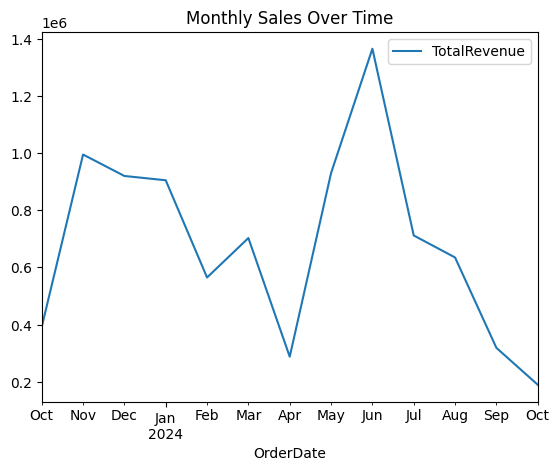

In [248]:
import matplotlib.pyplot as plt
df = pd.read_csv("ecommerce_sales_data.csv")
# 2. **매출 분석**
#      1. **매출액**(총 판매 금액)을 계산하는 새로운 열 `TotalRevenue`를 생성하세요.
#         - 매출액 = `Quantity` * `Price`
#      2. 월별 총 매출액을 집계하여 시각화하세요.
#         - 힌트: `resample()`을 사용하여 월별로 데이터를 집계하세요.

# 1
df["TotalRevenue"] = df["Quantity"] * df["Price"]
print(df)
# 2
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df = df.set_index('OrderDate')
monthly_sales = df.resample('M')[['TotalRevenue']].sum()  # 'M'은 월별 집계를 의미

# 시계열 데이터 시각화
monthly_sales.plot(title='Monthly Sales Over Time')
plt.show()


In [ ]:
df = pd.read_csv("ecommerce_sales_data.csv")
# 3. **고객 분석**
#     1. 고객별로 총 매출액을 계산한 후, 상위 5명의 고객을 출력하세요.
#     2. 주문 횟수가 가장 많은 상위 5명의 고객을 출력하세요.
#     3. **연령대**에 따라 고객을 분류하고, 각 연령대별로 가장 많이 구매한 상품의 카테고리를 구하세요.
#         - 힌트: 고객의 연령대는 따로 제공되지 않으므로, 가정 데이터를 추가해 임의로 분류할 수 있습니다.

# 1
df["TotalRevenue"] = df["Quantity"] * df["Price"]

df = df.groupby("CustomerID",as_index=False)["TotalRevenue"].sum()
df.head()

# 2
df = pd.read_csv("ecommerce_sales_data.csv")

df = df.groupby("CustomerID",as_index=False)["OrderID"].count().sort_values("OrderID",ascending=False)

df.head()

# 3

,CustomerID,OrderID
0,1007,2
3,1038,2
16,1141,2
31,1278,2
43,1421,2


In [ ]:
# 4. **상품 분석**
#     1. 가장 많이 판매된 상위 5개의 상품을 출력하세요.
#     2. **카테고리별**로 가장 많이 판매된 상품을 찾아 출력하세요.
#     3. **평균 구매 수량**이 가장 높은 상위 3개의 상품을 출력하세요.



In [ ]:
# 5. **시간 분석**
#     1. 주문 날짜별로 **주별** 매출액을 계산하고 시각화하세요.
#     2. 특정 기간(예: 2024년 1월 ~ 2024년 6월) 동안의 매출 추이를 분석하고 시각화하세요.
#     3. 특정 국가에서 가장 많이 주문한 시간대를 분석하고, 이를 시각화하여 인사이트를 도출하세요.


In [ ]:
# 6. **추가 분석**
#     1. 고객의 **재구매율**을 분석하세요.
#         - 재구매율 = 한 고객이 여러 번 주문한 비율
#     2. 상품 카테고리별 **할인**을 적용한 판매 데이터를 사용하여 할인율이 높은 카테고리의 매출액을 분석하세요.